<a href="https://colab.research.google.com/github/oselumeseagbonrofo/nlp-scripts/blob/main/hf_audio_preprocessing_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is a tutorial on loading audio datasets from hugging face

Import required libraries

In [ ]:
pip install datasets[audio] soundfile librosa torchcodec

Load **minds14** audio dataset (which contains recordings of people asking an e-banking system questions in several languages and dialects)

In [ ]:
from datasets import load_dataset

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

Output one row of the data as an example

In [ ]:
example = minds[0]
example

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f67d0963b60>,
 'transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'english_transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'intent_class': 13,
 'lang_id': 2}

Convert intent class to string value

In [ ]:
id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

'pay_bill'

Remove unneeded data

In [ ]:
columns_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(columns_to_remove)
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})

Use Blocks and Audio features from Gradio to listen/ decode a few random samples from the dataset

In [ ]:
import gradio as gr


def generate_audio():
    example = minds.shuffle()[0]
    audio = example["audio"]
    return (
        audio["sampling_rate"],
        audio["array"],
    ), id2label(example["intent_class"])


with gr.Blocks() as demo:
    with gr.Column():
        for _ in range(4):
            audio, label = generate_audio()
            output = gr.Audio(audio, label=label)

demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().


KeyboardInterrupt: 

Plot the waveform of the first example

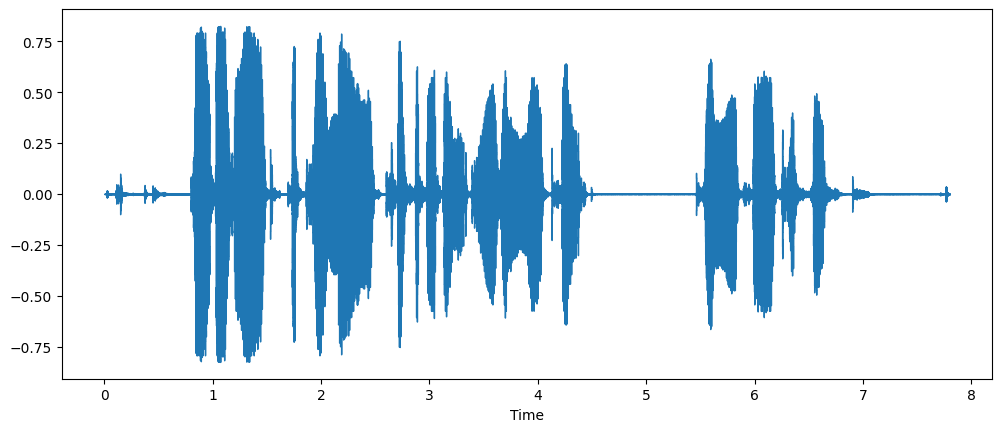

In [ ]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

Visualise for Korea

In [ ]:
korea_data = load_dataset("PolyAI/minds14", name="ko-KR", split="train")
korea_data
korea_data[0]

In [ ]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

array = korea_data[0]["audio"]["array"]
sampling_rate = korea_data[0]["audio"]["sampling_rate"]

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

In [ ]:
import gradio as gr


def generate_audio():
    example = korea_data.shuffle()[0]
    audio = korea_data[0]["audio"]
    return (
        audio["sampling_rate"],
        audio["array"],
    ), id2label(example["intent_class"])


with gr.Blocks() as demo:
    with gr.Column():
        for _ in range(4):
            audio, label = generate_audio()
            output = gr.Audio(audio, label=label)

demo.launch(debug=True)

Audio Preprocessing

1. Resampling

Upsample audio from 8Khz to 16khZ

In [ ]:
from datasets import Audio
first_audio = minds[0]["audio"]
print(f"Initial Sampling rate: {first_audio["sampling_rate"]}\n Initial Array {first_audio["array"]}")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))
updated_audio = minds[0]["audio"]
print(f"After modifying sampling rate: Sampling rate: {updated_audio["sampling_rate"]}\n After modifying sampling rate Array {updated_audio["array"]}")

Initial Sampling rate: 8000
 Initial Array [ 0.          0.00024414 -0.00024414 ... -0.00024414  0.00024414
  0.0012207 ]
After modifying sampling rate: Sampling rate: 16000
 After modifying sampling rate Array [0.         0.00012415 0.00024414 ... 0.00071331 0.0012207  0.00144803]


2. Filtering dataset

Filter audio greater than 20 secs

In [ ]:
MAX_DURATION_IN_SECONDS = 20.0


def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS

In [ ]:
import librosa

# use librosa to get example's duration from the audio file
new_column = [
    librosa.get_duration(y=x["array"], sr=x["sampling_rate"]) for x in minds["audio"]
]
minds = minds.add_column("duration", new_column)

# use 🤗 Datasets' `filter` method to apply the filtering function
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])

# remove the temporary helper column
minds = minds.remove_columns(["duration"])
minds

Filter:   0%|          | 0/654 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 624
})

## Pre-processing audio data.
Transformers library has a feature extractor class that converts raw audio data into the input features the model expects.

In [ ]:
from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

preprocessor_config.json: 0.00B [00:00, ?B/s]

In [ ]:
def prepare_dataset(example):
    audio = example["audio"]

    if audio["sampling_rate"] != 16000:
        audio_array = librosa.resample(
            audio["array"], orig_sr=audio["sampling_rate"], target_sr=16000
        )
        audio = {"array": audio_array, "sampling_rate": 16000}

    features = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"], padding=True
    )
    return features

Apply data preparation fxn to all training examples using Datasets map method

In [ ]:
minds = minds.map(prepare_dataset)
minds

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class', 'input_features'],
    num_rows: 624
})

Visualize Pre-processed Minds14 dataset

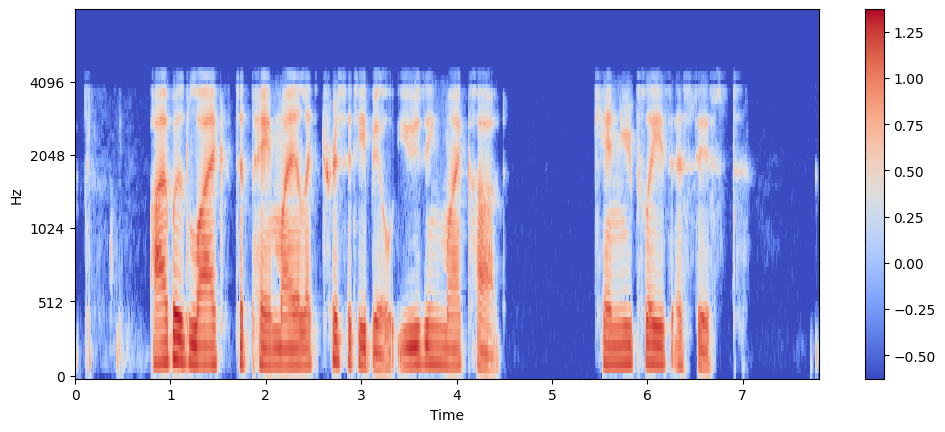

In [ ]:
import numpy as np

example = minds[0]
input_features = example["input_features"]

plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(input_features[0]),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()

For dealing with multimodal data (text & audio), both needed to be preprocessed using seperate feature extractors (audio) and tokenizers (for text). Example of task is speech recognition. You need to be able to handle both the audio and the  text

Hugging Face provides an AutoProcessor class to enable both tasks to be combined together easily

In [ ]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("openai/whisper-small")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
def preprocess_audio_text_dataset(example):
    audio = example["audio"]
    text = example["transcription"]

    if audio["sampling_rate"] != 16000:
        audio_array = librosa.resample(
            audio["array"], orig_sr=audio["sampling_rate"], target_sr=16000
        )
        audio = {"array": audio_array, "sampling_rate": 16000}

    features = processor(
        audio= audio["array"], sampling_rate=audio["sampling_rate"],
        padding=True,
        text = text
    )
    return features

In [ ]:
minds.map(preprocess_audio_text_dataset)

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class', 'input_features', 'labels'],
    num_rows: 624
})

In [ ]:
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class', 'input_features'],
    num_rows: 624
})

# Dataset streaming

Authenticate on hugging face

In [ ]:
from google.colab import userdata
import os

# This pulls the secret you just created
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
gigaspeech = load_dataset("speechcolab/gigaspeech", "xs", streaming=True)

Note: indexing can't be done when streaming a datset. You can only access a sample by iterating over the dataset

In [ ]:
next(iter(gigaspeech["train"]))

{'segment_id': 'YOU0000000315_S0000660',
 'speaker': 'N/A',
 'text': "AS THEY'RE LEAVING <COMMA> CAN KASH PULL ZAHRA ASIDE REALLY QUICKLY <QUESTIONMARK>",
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f6770ebdcd0>,
 'begin_time': 2941.889892578125,
 'end_time': 2945.070068359375,
 'audio_id': 'YOU0000000315',
 'title': 'Return to Vasselheim | Critical Role: VOX MACHINA | Episode 43',
 'url': 'https://www.youtube.com/watch?v=zr2n1fLVasU',
 'source': 2,
 'category': 24,
 'original_full_path': 'audio/youtube/P0004/YOU0000000315.opus'}

To load first 2 rows

In [ ]:
gigaspeech_head = gigaspeech["train"].take(2)
list(gigaspeech_head)

[{'segment_id': 'YOU0000000315_S0000660',
  'speaker': 'N/A',
  'text': "AS THEY'RE LEAVING <COMMA> CAN KASH PULL ZAHRA ASIDE REALLY QUICKLY <QUESTIONMARK>",
  'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f6770da25a0>,
  'begin_time': 2941.889892578125,
  'end_time': 2945.070068359375,
  'audio_id': 'YOU0000000315',
  'title': 'Return to Vasselheim | Critical Role: VOX MACHINA | Episode 43',
  'url': 'https://www.youtube.com/watch?v=zr2n1fLVasU',
  'source': 2,
  'category': 24,
  'original_full_path': 'audio/youtube/P0004/YOU0000000315.opus'},
 {'segment_id': 'AUD0000001043_S0000775',
  'speaker': 'N/A',
  'text': 'SIX TOMATOES <PERIOD>',
  'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f6770da07d0>,
  'begin_time': 3673.9599609375,
  'end_time': 3675.260009765625,
  'audio_id': 'AUD0000001043',
  'title': 'Asteroid of Fear',
  'url': 'http//www.archive.org/download/asteroid_of_fear_1012_librivox/asteroid_of_fear_1012_librivox_64kb_mp3.zip',
  'source': 0,
  